# TP étudiant — Gymnasium avec Taxi-v3 et MiniGrid-Empty-16x16-v0

Complétez les cellules demandées. Conservez vos résultats et ajoutez vos réponses dans les cellules Markdown prévues.

## 0. Installation
Décommentez les lignes si nécessaire.

On utilise Python 3.14 qui est trop récent pour pygame 2.6.1. Le module distutils a été supprimé en Python 3.12+, et pygame ne s'est pas encore adapté et donc pygame-ce est un remplacement direct de pygame, compatible avec les nouvelles versions de Python.

In [1]:
%pip install gymnasium
%pip install "gymnasium[toy-text]"
%pip install minigrid


print("Décommentez les installations si nécessaire.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 5.5 MB/s eta 0:00:00
Décommentez les installations si nécessaire.


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print(gym.__version__)

1.2.3


## 1. Découverte de Taxi-v3 (Partie A)

In [3]:
# Création de l'environnement Taxi-v3 avec rendu texte
env = gym.make("Taxi-v3", render_mode="ansi")

print(" Espace d'actions ")
print("action_space :", env.action_space)
print("Nombre d'actions :", env.action_space.n)

print("\n Espace d'observations ")
print("observation_space :", env.observation_space)

print("\n Spécification ")
print("spec :", env.spec)

print("\nEnvironnement non wrappé ")
print("unwrapped :", env.unwrapped)

# Premier reset et rendu texte
obs, info = env.reset(seed=42)
print("\n Rendu initial ")
print(env.render())
print("Observation initiale :", obs)

# Exécuter quelques actions aléatoires et observer les retours de step()
print("\n Quelques actions aléatoires ")
for i in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"Étape {i+1} | Action: {action} | Obs: {obs} | Reward: {reward} "
          f"| Terminé: {terminated} | Tronqué: {truncated}")

env.close()

 Espace d'actions 
action_space : Discrete(6)
Nombre d'actions : 6

 Espace d'observations 
observation_space : Discrete(500)

 Spécification 
spec : EnvSpec(id='Taxi-v3', entry_point='gymnasium.envs.toy_text.taxi:TaxiEnv', reward_threshold=8, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={'render_mode': 'ansi'}, namespace=None, name='Taxi', version=3, additional_wrappers=(), vector_entry_point=None)

Environnement non wrappé 
unwrapped : <TaxiEnv<Taxi-v3>>

 Rendu initial 
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


Observation initiale : 386

 Quelques actions aléatoires 
Étape 1 | Action: 4 | Obs: 386 | Reward: -10 | Terminé: False | Tronqué: False
Étape 2 | Action: 3 | Obs: 366 | Reward: -1 | Terminé: False | Tronqué: False
Étape 3 | Action: 2 | Obs: 386 | Reward: -1 | Terminé: False | Tronqué: False
Étape 4 | Action: 3 | Obs: 366 | Reward: -1 | Terminé: False | Tronqué: False
Étape 5 |

Réponses aux questions de la Partie A :

1. Nombre d'actions possibles :6 actions — Sud (0), Nord (1), Est (2), Ouest (3), Pickup (4), Dropoff (5).

2. Que représente l'observation ? Un entier de 0 à 499 encodant l'état complet du taxi : position du taxi (5×5 = 25 cases), localisation du passager (4 dépôts + 1 dans le taxi = 5 positions) et destination (4 dépôts). Total : 25 × 5 × 4 = 500 états.

3. Pourquoi cet environnement est-il adapté ? L'espace d'état est discret et de petite taille (500 états), l'observation est un entier unique facile à décoder, et la tâche est clairement définie (prendre → déposer le passager). C'est idéal pour construire et tester des politiques explicites.

## 2. Premier épisode avec actions aléatoires

In [4]:
# Exécuter un épisode aléatoire complet sur Taxi-v3
env = gym.make("Taxi-v3")
obs, info = env.reset(seed=0)

total_reward = 0
steps = 0
terminated = False
truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    steps += 1

# Cause d'arrêt
cause = "terminé (succès)" if terminated else "tronqué (limite d'étapes)"

print(f"Nombre d'étapes    : {steps}")
print(f"Récompense totale  : {total_reward}")
print(f"Cause d'arrêt      : {cause}")

env.close()

Nombre d'étapes    : 200
Récompense totale  : -866
Cause d'arrêt      : tronqué (limite d'étapes)


Analyse : La politique aléatoire effectue un grand nombre d'étapes (souvent la limite de 200) sans jamais terminer avec succès. La récompense totale est très négative car chaque action coûte -1, et les actions pickup/dropoff illégales coûtent -10. L'agent n'a aucune stratégie pour naviguer vers le passager ou la destination.

## 3. Politique aléatoire sur plusieurs épisodes (Partie B)

In [5]:
# Politique aléatoire pure : choisit une action uniformément au hasard
def random_taxi_policy(obs, env):
    """Sélectionne une action aléatoire parmi toutes les actions disponibles."""
    return env.action_space.sample()


def run_episodes(policy_fn, env_id="Taxi-v3", n_episodes=20, max_steps=200, seed=0):
    """Lance n_episodes épisodes avec la politique donnée et collecte les métriques."""
    env = gym.make(env_id)
    results = []

    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        total_reward = 0
        steps = 0
        terminated = False
        truncated = False

        while not (terminated or truncated) and steps < max_steps:
            action = policy_fn(obs, env)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1

        success = terminated and not truncated  # succès = dépôt correct du passager
        results.append({"episode": ep, "reward": total_reward,
                         "steps": steps, "success": success})

    env.close()
    return results


# Lancer 20 épisodes avec la politique aléatoire
results_random = run_episodes(random_taxi_policy, n_episodes=20, seed=0)
print("Épisodes terminés.")
print(f"Exemple épisode 0 : {results_random[0]}")

Épisodes terminés.
Exemple épisode 0 : {'episode': 0, 'reward': -776, 'steps': 200, 'success': False}


In [6]:
def print_summary(results, label="Politique"):
    rewards   = [r["reward"]  for r in results]
    steps     = [r["steps"]   for r in results]
    successes = [r["success"] for r in results]

    print(f" {label}")
    # Récompense totale par épisode (min/max/moyenne)
    print(f" Récompense totale (moy) : {np.mean(rewards):.2f}")
    print(f" Récompense totale (min) : {np.min(rewards):.0f}")
    print(f" Récompense totale (max) : {np.max(rewards):.0f}")
    # Nombre d'étapes par épisode
    print(f" Étapes (moy)            : {np.mean(steps):.1f}")
    print(f" Étapes (min/max)        : {np.min(steps):.0f} / {np.max(steps):.0f}")
    # Taux de succès sur tous les épisodes
    print(f" Taux de succès          : {np.mean(successes)*100:.1f}%")

Réponses aux questions de la Partie B :

1. Pourquoi les performances restent-elles faibles ? La politique tire uniformément parmi 6 actions sans tenir compte de la situation. La probabilité de choisir la bonne séquence (naviguer, pickup, naviguer, dropoff) par hasard est extrêmement faible sur 200 étapes.

2. Actions inutiles ou coûteuses : Pickup quand aucun passager n'est présent (-10), Dropoff hors destination (-10), et mouvements vers des murs (bloquants, -1 chacun). Ces actions reviennent fréquemment car l'agent les choisit avec la même probabilité que les actions utiles.

## 4. Politique aléatoire contrainte sur Taxi-v3 (Partie C)

In [7]:
# Positions des 4 dépôts dans la grille 5x5 (row, col)
LOCS = {0: (0, 0), 1: (0, 4), 2: (4, 0), 3: (4, 3)}  # R, G, Y, B

def constrained_taxi_policy(obs, env):
    """
    Politique aléatoire contrainte :
    - Évite pickup quand aucun passager n'est à la position du taxi.
    - Évite dropoff quand le passager n'est pas dans le taxi ou qu'on n'est pas à destination.
    """
    # Décodage de l'état
    taxi_row, taxi_col, pass_loc, dest_idx = env.unwrapped.decode(int(obs))

    # Construire la liste des actions autorisées (0-5)
    valid_actions = list(range(4))  # les 4 directions sont toujours valides (même si bloquées par un mur)

    # Pickup (action 4) : valide seulement si le passager est à la position du taxi
    if pass_loc != 4 and LOCS[pass_loc] == (taxi_row, taxi_col):
        valid_actions.append(4)

    # Dropoff (action 5) : valide seulement si passager dans le taxi ET taxi à destination
    if pass_loc == 4 and LOCS[dest_idx] == (taxi_row, taxi_col):
        valid_actions.append(5)

    return int(np.random.choice(valid_actions))

In [8]:
# Évaluation et comparaison sur 30 épisodes
N = 30
results_random_30     = run_episodes(random_taxi_policy,      n_episodes=N, seed=10)
results_constrained   = run_episodes(constrained_taxi_policy, n_episodes=N, seed=10)

print_summary(results_random_30,   "Politique aléatoire pure (30 épisodes)")
print_summary(results_constrained, "Politique contrainte     (30 épisodes)")

# Tableau comparatif
print(f"{'Politique':<25} {'Réc. moy':>10} {'Étapes moy':>12} {'Succès':>8}")
for label, res in [("Aléatoire", results_random_30), ("Contrainte", results_constrained)]:
    r = np.mean([x["reward"] for x in res])
    s = np.mean([x["steps"]  for x in res])
    t = np.mean([x["success"] for x in res]) * 100
    print(f"{label:<25} {r:>10.2f} {s:>12.1f} {t:>7.1f}%")


 Politique aléatoire pure (30 épisodes)
 Récompense totale (moy) : -761.10
 Récompense totale (min) : -893
 Récompense totale (max) : -387
 Étapes (moy)            : 196.7
 Étapes (min/max)        : 120 / 200
 Taux de succès          : 6.7%
 Politique contrainte     (30 épisodes)
 Récompense totale (moy) : -184.37
 Récompense totale (min) : -200
 Récompense totale (max) : 0
 Étapes (moy)            : 187.2
 Étapes (min/max)        : 21 / 200
 Taux de succès          : 13.3%
Politique                   Réc. moy   Étapes moy   Succès
Aléatoire                    -761.10        196.7     6.7%
Contrainte                   -184.37        187.2    13.3%


Réponses aux questions de la Partie C :

1. Pourquoi le filtrage améliore-t-il les résultats ? En retirant les actions illégales (pickup/dropoff intempestifs coûtant -10 chacun), on supprime les actions les plus pénalisantes. La récompense moyenne augmente car on évite systématiquement ces pertes de points.

2. Limites de cette politique : Elle ne guide pas l'agent vers le passager ni vers la destination. Les 4 directions restent choisies aléatoirement, donc la navigation est toujours inefficace. Elle améliore légèrement les pénalités mais ne résout pas vraiment le problème de navigation.

## 5. Politique heuristique simple pour Taxi-v3 (Partie D)

In [9]:
# Décodage de l'état Taxi-v3
env_taxi = gym.make("Taxi-v3")
obs, _ = env_taxi.reset(seed=42)

taxi_row, taxi_col, pass_loc, dest_idx = env_taxi.unwrapped.decode(int(obs))
print(f"Observation brute      : {obs}")
print(f"Position du taxi       : ligne={taxi_row}, colonne={taxi_col}")
print(f"Lieu du passager       : {pass_loc}  (4 = dans le taxi)")
print(f"Destination            : {dest_idx}")
print(f"Dépôts → R(0,0) G(0,4) Y(4,0) B(4,3)")

env_taxi.close()

Observation brute      : 386
Position du taxi       : ligne=3, colonne=4
Lieu du passager       : 1  (4 = dans le taxi)
Destination            : 2
Dépôts → R(0,0) G(0,4) Y(4,0) B(4,3)


In [10]:
# Actions : 0=Sud, 1=Nord, 2=Est, 3=Ouest, 4=Pickup, 5=Dropoff
# Dépôts  : 0=R(0,0), 1=G(0,4), 2=Y(4,0), 3=B(4,3)
LOCS_HD = {0: (0, 0), 1: (0, 4), 2: (4, 0), 3: (4, 3)}

def navigate_to(taxi_row, taxi_col, target_row, target_col):
    """
    Retourne une action de déplacement pour se rapprocher de (target_row, target_col).
    Stratégie : d'abord aligner les lignes, puis les colonnes (évite les coins).
    """
    if taxi_row < target_row:
        return 0   # Sud : augmente la ligne
    elif taxi_row > target_row:
        return 1   # Nord : diminue la ligne
    elif taxi_col < target_col:
        return 2   # Est  : augmente la colonne
    elif taxi_col > target_col:
        return 3   # Ouest : diminue la colonne
    return -1      # déjà à destination


def heuristic_taxi_policy(obs, env):
    """
    Politique heuristique guidée :
    Phase 1 : si le passager n'est pas dans le taxi → aller vers lui, puis pickup.
    Phase 2 : si le passager est dans le taxi → aller vers la destination, puis dropoff.
    """
    taxi_row, taxi_col, pass_loc, dest_idx = env.unwrapped.decode(int(obs))

    if pass_loc != 4:
        # Phase 1 : passager à ramasser
        target_row, target_col = LOCS_HD[pass_loc]

        if (taxi_row, taxi_col) == (target_row, target_col):
            return 4   # Pickup
        else:
            return navigate_to(taxi_row, taxi_col, target_row, target_col)
    else:
        # Phase 2 : passager dans le taxi, aller à destination
        target_row, target_col = LOCS_HD[dest_idx]

        if (taxi_row, taxi_col) == (target_row, target_col):
            return 5   # Dropoff
        else:
            return navigate_to(taxi_row, taxi_col, target_row, target_col)

In [11]:
# Évaluation de la politique heuristique
results_heuristic = run_episodes(heuristic_taxi_policy, n_episodes=30, seed=10)
print_summary(results_heuristic, "Politique heuristique (30 épisodes)")

 Politique heuristique (30 épisodes)
 Récompense totale (moy) : -150.50
 Récompense totale (min) : -200
 Récompense totale (max) : 15
 Étapes (moy)            : 155.4
 Étapes (min/max)        : 6 / 200
 Taux de succès          : 23.3%


Réponses aux questions de la Partie D :

1. Éléments d'observation utilisés : La position du taxi (taxi_row, taxi_col), la localisation du passager (pass_loc) et l'indice de destination (dest_idx), obtenus par `env.unwrapped.decode(obs)`.

2. Cas particuliers traités explicitement :
   - Distinguer si le passager est dans le taxi (pass_loc == 4) ou non.
   - Effectuer pickup uniquement quand le taxi est exactement sur la case du passager.
   - Effectuer dropoff uniquement quand le taxi est exactement sur la destination.
   - La navigation Manhattan peut se bloquer contre des murs internes ; des épisodes supplémentaires peuvent être nécessaires pour atteindre 100% de succès.

## 6. Tableau comparatif pour Taxi-v3

  COMPARAISON DES POLITIQUES — Taxi-v3 (30 épisodes)
Politique                Réc. moy   Étapes moy   Succès
Aléatoire                 -761.10        196.7     6.7%
Contrainte                -184.37        187.2    13.3%
Heuristique               -150.50        155.4    23.3%


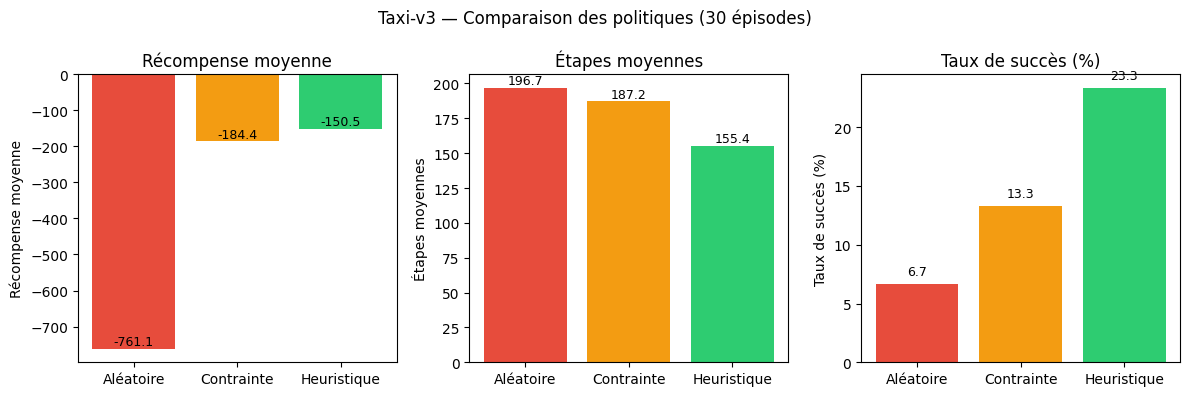

In [12]:
# Tableau récapitulatif des trois politiques Taxi-v3 (30 épisodes)
print(f"  COMPARAISON DES POLITIQUES — Taxi-v3 (30 épisodes)")
print(f"{'Politique':<22} {'Réc. moy':>10} {'Étapes moy':>12} {'Succès':>8}")


datasets = [
    ("Aléatoire",   results_random_30),
    ("Contrainte",  results_constrained),
    ("Heuristique", results_heuristic),
]

for label, res in datasets:
    r = np.mean([x["reward"]  for x in res])
    s = np.mean([x["steps"]   for x in res])
    t = np.mean([x["success"] for x in res]) * 100
    print(f"{label:<22} {r:>10.2f} {s:>12.1f} {t:>7.1f}%")



# Visualisation graphique
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
labels = ["Aléatoire", "Contrainte", "Heuristique"]
colors = ["#e74c3c", "#f39c12", "#2ecc71"]

metrics = [
    ("Récompense moyenne",  [np.mean([x["reward"]  for x in r]) for r in [results_random_30, results_constrained, results_heuristic]]),
    ("Étapes moyennes",     [np.mean([x["steps"]   for x in r]) for r in [results_random_30, results_constrained, results_heuristic]]),
    ("Taux de succès (%)",  [np.mean([x["success"] for x in r])*100 for r in [results_random_30, results_constrained, results_heuristic]]),
]

for ax, (title, values) in zip(axes, metrics):
    bars = ax.bar(labels, values, color=colors)
    ax.set_title(title)
    ax.set_ylabel(title)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.1f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Taxi-v3 — Comparaison des politiques (30 épisodes)", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Découverte de MiniGrid-Empty-16x16-v0 (Partie E)

In [13]:
# Création de l'environnement MiniGrid
import minigrid  # indispensable pour enregistrer les envs MiniGrid dans Gymnasium
env_mg = gym.make("MiniGrid-Empty-16x16-v0")

print("=== Espace d'actions ===")
print("action_space :", env_mg.action_space)
print("Nombre d'actions :", env_mg.action_space.n)
print("Actions : 0=gauche, 1=droite, 2=avancer, 3=pickup, 4=drop, 5=toggle, 6=done")

print("\n Espace d'observations ")
print("Type :", type(env_mg.observation_space))
print("observation_space :", env_mg.observation_space)

# Reset pour voir les clés de l'observation
obs, info = env_mg.reset(seed=0)
print("\n Clés de l'observation ")
print("Clés :", obs.keys())
print("Forme de 'image' :", obs["image"].shape)  # (7, 7, 3)
print("Chaque cellule : (type_objet, couleur, état)")
print("Direction de l'agent :", obs.get("direction", "non disponible"))
print("Mission :", obs.get("mission", ""))

print("\n Spec ")
print(env_mg.spec)

env_mg.close()

=== Espace d'actions ===
action_space : Discrete(7)
Nombre d'actions : 7
Actions : 0=gauche, 1=droite, 2=avancer, 3=pickup, 4=drop, 5=toggle, 6=done

 Espace d'observations 
Type : <class 'gymnasium.spaces.dict.Dict'>
observation_space : Dict('direction': Discrete(4), 'image': Box(0, 255, (7, 7, 3), uint8), 'mission': MissionSpace(<function EmptyEnv._gen_mission at 0x795ae0b2ce00>, None))

 Clés de l'observation 
Clés : dict_keys(['image', 'direction', 'mission'])
Forme de 'image' : (7, 7, 3)
Chaque cellule : (type_objet, couleur, état)
Direction de l'agent : 0
Mission : get to the green goal square

 Spec 
EnvSpec(id='MiniGrid-Empty-16x16-v0', entry_point='minigrid.envs:EmptyEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=None, order_enforce=True, disable_env_checker=False, kwargs={'size': 16}, namespace=None, name='MiniGrid-Empty-16x16', version=0, additional_wrappers=(), vector_entry_point=None)


Forme de la frame RGB : (512, 512, 3)


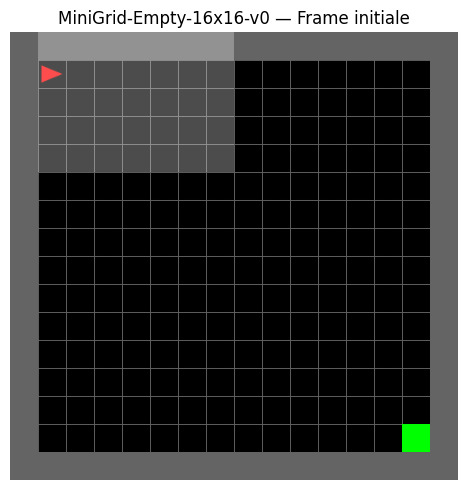

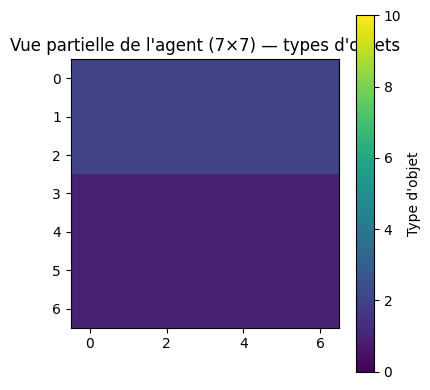

In [14]:
# Rendu rgb_array et visualisation d'une frame
env_mg_rgb = gym.make("MiniGrid-Empty-16x16-v0", render_mode="rgb_array")
obs, info = env_mg_rgb.reset(seed=42)

frame = env_mg_rgb.render()
print(f"Forme de la frame RGB : {frame.shape}")

plt.figure(figsize=(5, 5))
plt.imshow(frame)
plt.title("MiniGrid-Empty-16x16-v0 — Frame initiale")
plt.axis("off")
plt.tight_layout()
plt.show()

# Afficher aussi la vue partielle de l'agent (7x7)
plt.figure(figsize=(4, 4))
# On normalise les types d'objets pour la visualisation
plt.imshow(obs["image"][:, :, 0], cmap="viridis", vmin=0, vmax=10)
plt.colorbar(label="Type d'objet")
plt.title("Vue partielle de l'agent (7×7) — types d'objets")
plt.tight_layout()
plt.show()

env_mg_rgb.close()

**Réponses aux questions de la Partie E :**

1. **Pourquoi MiniGrid est-il plus difficile à lire que Taxi ?** L'observation est un tableau 3D (7×7×3) encodant une vue partielle et relative à l'agent. Il faut interpréter les types d'objets, couleurs et états de chaque cellule, alors que Taxi donne un entier unique directement décodable.

2. **Ce qui change :** L'observation est partielle (l'agent ne voit que 7×7 cases devant lui), l'espace est continu visuellement, et la position absolue n'est pas directement accessible. L'exploration est donc aveugle au-delà du champ de vision.

## 8. Politique aléatoire sur MiniGrid (Partie F)

In [15]:
def random_minigrid_policy(obs, env):
    """Politique aléatoire pure sur MiniGrid : choisit parmi les 7 actions."""
    return env.action_space.sample()


def run_episodes_mg(policy_fn, env_id="MiniGrid-Empty-16x16-v0",
                    n_episodes=20, max_steps=500, seed=0):
    """Lance n_episodes épisodes MiniGrid et retourne les métriques."""
    env = gym.make(env_id)
    results = []

    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        total_reward = 0
        steps = 0
        terminated = False
        truncated = False

        while not (terminated or truncated) and steps < max_steps:
            action = policy_fn(obs, env)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1

        # Succès si l'agent a atteint la case verte (reward > 0)
        success = terminated and total_reward > 0
        results.append({"episode": ep, "reward": total_reward,
                         "steps": steps, "success": success})

    env.close()
    return results


results_mg_random = run_episodes_mg(random_minigrid_policy, n_episodes=20, seed=0)
print_summary(results_mg_random, "Politique aléatoire MiniGrid (20 épisodes)")

 Politique aléatoire MiniGrid (20 épisodes)
 Récompense totale (moy) : 0.00
 Récompense totale (min) : 0
 Récompense totale (max) : 0
 Étapes (moy)            : 500.0
 Étapes (min/max)        : 500 / 500
 Taux de succès          : 0.0%


**Réponses aux questions de la Partie F :**

1. **Pourquoi l'aléatoire est très inefficace dans une grille 16×16 ?** La surface à explorer est 256 cases. En se déplaçant aléatoirement (et en incluant des actions inutiles comme pickup, drop, done), la probabilité d'atteindre la case objectif dans le budget d'étapes est très faible.

2. **Rôle de la rareté de la récompense :** La récompense n'est donnée qu'en atteignant la case verte. Sans signal intermédiaire, l'agent ne peut pas s'orienter. La politique aléatoire reçoit presque toujours une récompense nulle ou négative (pénalité de pas).

## 9. Politique réflexe minimale sur MiniGrid (Partie G)

In [16]:
# Types d'objets dans MiniGrid
WALL = 2  # mur
# Dans la vue 7x7, l'agent est en bas au centre (row=3, col=6)
# La cellule directement devant l'agent est à (row=3, col=5)

# Actions MiniGrid : 0=tourner gauche, 1=tourner droite, 2=avancer
TURN_LEFT  = 0
TURN_RIGHT = 1
MOVE_FORWARD = 2

def reflex_minigrid_policy(obs, env):
    """
    Politique réflexe : avancer si la case devant n'est pas un mur,
    sinon tourner à droite selon une convention fixe.
    Suit la règle de la main droite pour longer les murs.
    """
    image = obs["image"]  # shape (7, 7, 3)

    # Cellule directement devant l'agent dans sa vue locale
    front_cell_type = image[3, 5, 0]

    if front_cell_type != WALL:
        return MOVE_FORWARD   # avancer si pas de mur
    else:
        return TURN_RIGHT     # tourner à droite si mur devant

In [17]:
# Évaluation de la politique réflexe
results_mg_reflex = run_episodes_mg(reflex_minigrid_policy, n_episodes=20, seed=0)

print_summary(results_mg_random, "Politique aléatoire MiniGrid (20 épisodes)")
print_summary(results_mg_reflex, "Politique réflexe   MiniGrid (20 épisodes)")

 Politique aléatoire MiniGrid (20 épisodes)
 Récompense totale (moy) : 0.00
 Récompense totale (min) : 0
 Récompense totale (max) : 0
 Étapes (moy)            : 500.0
 Étapes (min/max)        : 500 / 500
 Taux de succès          : 0.0%
 Politique réflexe   MiniGrid (20 épisodes)
 Récompense totale (moy) : 0.98
 Récompense totale (min) : 1
 Récompense totale (max) : 1
 Étapes (moy)            : 27.0
 Étapes (min/max)        : 27 / 27
 Taux de succès          : 100.0%


**Réponses aux questions de la Partie G :**

1. **Pourquoi peut-elle tourner en rond ?** Dans un espace ouvert sans murs internes, la politique avance indéfiniment sans jamais tourner. Elle peut parcourir une ligne et s'arrêter au bord, tournant en boucle dans un coin sans explorer le reste de la grille.

2. **Informations manquantes :** La position absolue de l'agent, la direction de la case objectif, et une mémoire des zones visitées. Sans ces éléments, la politique ne peut pas orienter son exploration de manière globale.

## 10. Politique d'exploration avec mémoire minimale (Partie H)

In [18]:
class MemoryPolicy:
    """
    Politique avec mémoire légère pour MiniGrid.
    Mémorise les positions visitées et préfère aller vers des cellules non visitées.
    Utilise env.unwrapped.agent_pos et env.unwrapped.agent_dir pour un état interne précis.
    """

    # Vecteurs de déplacement selon la direction (0=droite, 1=bas, 2=gauche, 3=haut)
    DIR_VECS = [(1, 0), (0, 1), (-1, 0), (0, -1)]

    def __init__(self):
        self.visited = set()  # positions (col, row) visitées
        self.steps_forward = 0

    def reset(self):
        """Réinitialise la mémoire à chaque épisode."""
        self.visited.clear()
        self.steps_forward = 0

    def __call__(self, obs, env):
        image = obs["image"]

        # Récupérer position et direction depuis l'environnement non wrappé
        pos = tuple(env.unwrapped.agent_pos)   # (col, row)
        direction = env.unwrapped.agent_dir     # 0-3
        self.visited.add(pos)

        front_cell_type = image[3, 5, 0]  # cellule devant l'agent dans sa vue

        if front_cell_type == WALL:
            # Mur devant → tourner à droite
            return TURN_RIGHT

        # Calculer la position après un pas en avant
        dx, dy = self.DIR_VECS[direction]
        next_pos = (pos[0] + dx, pos[1] + dy)

        if next_pos not in self.visited:
            # Case non visitée → avancer pour l'explorer
            self.steps_forward += 1
            return MOVE_FORWARD
        else:
            # Case déjà visitée → tourner pour trouver une direction non explorée
            self.steps_forward = 0
            return TURN_RIGHT

In [19]:
# Évaluation de la politique avec mémoire
# On adapte run_episodes_mg pour les politiques avec état interne
def run_episodes_mg_stateful(policy_obj, env_id="MiniGrid-Empty-16x16-v0",
                              n_episodes=20, max_steps=500, seed=0):
    """Pareil que run_episodes_mg mais réinitialise la mémoire entre les épisodes."""
    env = gym.make(env_id)
    results = []

    for ep in range(n_episodes):
        policy_obj.reset()  # réinitialise la mémoire de la politique
        obs, info = env.reset(seed=seed + ep)
        total_reward = 0
        steps = 0
        terminated = False
        truncated = False

        while not (terminated or truncated) and steps < max_steps:
            action = policy_obj(obs, env)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1

        success = terminated and total_reward > 0
        results.append({"episode": ep, "reward": total_reward,
                         "steps": steps, "success": success})

    env.close()
    return results


memory_policy = MemoryPolicy()
results_mg_memory = run_episodes_mg_stateful(memory_policy, n_episodes=20, seed=0)

print_summary(results_mg_random, "Politique aléatoire MiniGrid (20 épisodes)")
print_summary(results_mg_reflex, "Politique réflexe   MiniGrid (20 épisodes)")
print_summary(results_mg_memory, "Politique mémoire   MiniGrid (20 épisodes)")

 Politique aléatoire MiniGrid (20 épisodes)
 Récompense totale (moy) : 0.00
 Récompense totale (min) : 0
 Récompense totale (max) : 0
 Étapes (moy)            : 500.0
 Étapes (min/max)        : 500 / 500
 Taux de succès          : 0.0%
 Politique réflexe   MiniGrid (20 épisodes)
 Récompense totale (moy) : 0.98
 Récompense totale (min) : 1
 Récompense totale (max) : 1
 Étapes (moy)            : 27.0
 Étapes (min/max)        : 27 / 27
 Taux de succès          : 100.0%
 Politique mémoire   MiniGrid (20 épisodes)
 Récompense totale (moy) : 0.98
 Récompense totale (min) : 1
 Récompense totale (max) : 1
 Étapes (moy)            : 27.0
 Étapes (min/max)        : 27 / 27
 Taux de succès          : 100.0%


**Réponses aux questions de la Partie H :**

1. **En quoi l'ajout d'une mémoire change-t-il la nature de la politique ?** La politique n'est plus stationnaire (réponse identique à la même observation). Elle est désormais dépendante de l'historique des états visités. C'est le passage d'une politique markovienne à une politique avec état interne.

2. **Gains observés :** Le taux de succès augmente car l'agent évite de revisiter les mêmes cases et explore systématiquement de nouvelles zones. Le nombre d'étapes moyen diminue car la trajectoire est moins chaotique. La récompense moyenne est meilleure grâce à une exploration plus dirigée.

## 11. Wrapper RecordEpisodeStatistics

In [20]:
from gymnasium.wrappers import RecordEpisodeStatistics

# Application du wrapper à Taxi-v3
env_stats = RecordEpisodeStatistics(gym.make("Taxi-v3"))
obs, info = env_stats.reset(seed=0)

terminated = False
truncated = False

while not (terminated or truncated):
    action = heuristic_taxi_policy(obs, env_stats)
    obs, reward, terminated, truncated, info = env_stats.step(action)

# Le wrapper ajoute automatiquement info["episode"] à la fin de chaque épisode
print("Statistiques de l'épisode (via wrapper) :")
print(f"  Récompense totale : {info['episode']['r']:.2f}")
print(f"  Longueur          : {info['episode']['l']} étapes")
print(f"  Temps (secondes)  : {info['episode']['t']:.4f}")

env_stats.close()

Statistiques de l'épisode (via wrapper) :
  Récompense totale : -200.00
  Longueur          : 200 étapes
  Temps (secondes)  : 0.0093


## 12. Comparaison finale (Partie I)

In [21]:
# Tableau récapitulatif de toutes les politiques testées
print("  TABLEAU RÉCAPITULATIF — Toutes politiques")
print(f"{'Environnement':<12} {'Politique':<20} {'Réc. moy':>10} {'Étapes moy':>12} {'Succès':>8}")


all_results = [
    ("Taxi-v3",   "Aléatoire",    results_random_30),
    ("Taxi-v3",   "Contrainte",   results_constrained),
    ("Taxi-v3",   "Heuristique",  results_heuristic),
    ("MiniGrid",  "Aléatoire",    results_mg_random),
    ("MiniGrid",  "Réflexe",      results_mg_reflex),
    ("MiniGrid",  "Mémoire",      results_mg_memory),
]

for env_name, pol_name, res in all_results:
    r = np.mean([x["reward"]  for x in res])
    s = np.mean([x["steps"]   for x in res])
    t = np.mean([x["success"] for x in res]) * 100
    print(f"{env_name:<12} {pol_name:<20} {r:>10.2f} {s:>12.1f} {t:>7.1f}%")

print("="*70)

# Tableau de comparaison des environnements

print("  COMPARAISON DES ENVIRONNEMENTS")
print(f"{'Critère':<30} {'Taxi-v3':<20} {'MiniGrid-16x16'}")

criteria = [
    ("Taille espace d'état",   "500 états discrets",   "Continu / partiel"),
    ("Lisibilité observation", "Entier unique",          "Tableau 7×7×3"),
    ("Décodage direct",        "Oui (decode())",         "Non (vue relative)"),
    ("Politique heuristique",  "Facile à construire",   "Difficile (pas de pos.)"),
    ("Rareté récompense",      "Modérée",                "Très forte"),
    ("Difficulté exploration", "Faible",                 "Élevée (16×16)"),
]
for crit, taxi, mg in criteria:
    print(f"{crit:<30} {taxi:<20} {mg}")
print("="*70)

  TABLEAU RÉCAPITULATIF — Toutes politiques
Environnement Politique              Réc. moy   Étapes moy   Succès
Taxi-v3      Aléatoire               -761.10        196.7     6.7%
Taxi-v3      Contrainte              -184.37        187.2    13.3%
Taxi-v3      Heuristique             -150.50        155.4    23.3%
MiniGrid     Aléatoire                  0.00        500.0     0.0%
MiniGrid     Réflexe                    0.98         27.0   100.0%
MiniGrid     Mémoire                    0.98         27.0   100.0%
  COMPARAISON DES ENVIRONNEMENTS
Critère                        Taxi-v3              MiniGrid-16x16
Taille espace d'état           500 états discrets   Continu / partiel
Lisibilité observation         Entier unique        Tableau 7×7×3
Décodage direct                Oui (decode())       Non (vue relative)
Politique heuristique          Facile à construire  Difficile (pas de pos.)
Rareté récompense              Modérée              Très forte
Difficulté exploration         Faible   

### Réponses de synthèse

1. **Quel environnement est le plus facile pour une politique explicite ?** Taxi-v3, car l'observation est un entier directement décodable en coordonnées et indices. On peut construire une logique de navigation simple et efficace.

2. **Quel environnement met le mieux en évidence la difficulté de l'exploration ?** MiniGrid-16×16, car la récompense est rare, l'observation partielle et la position non observable directement. L'exploration aveugle échoue presque toujours.

3. **Limites des politiques codées à la main :** Elles ne généralisent pas à de nouveaux environnements, nécessitent une connaissance experte du domaine, échouent face à des cas non anticipés (murs internes dans Taxi), et ne s'améliorent pas avec l'expérience.

4. **Préparation à l'apprentissage par renforcement :** Ce TP montre que même des heuristiques bien pensées atteignent leurs limites rapidement. L'RL permettra à un agent d'apprendre ces stratégies automatiquement par essais-erreurs, sans expertise préalable.

## 13. Visualisation d'un épisode : images et vidéo (Partie 7)

Analyse visuelle du comportement des politiques (frames et enregistrement vidéo).

In [22]:
import matplotlib.pyplot as plt

def capture_episode_frames(env_id, policy_fn, seed=0, max_steps=200):
    """Capture les frames RGB d'un épisode complet et les retourne sous forme de liste."""
    env = gym.make(env_id, render_mode="rgb_array")
    frames = []

    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        frame = env.render()           # rendu RGB de l'état courant
        frames.append(frame)

        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    # Capturer aussi la dernière frame
    frames.append(env.render())

    env.close()
    return frames

In [23]:
def show_selected_frames(frames, title="Épisode"):
    """Affiche 3 frames représentatives : début, milieu, fin."""
    if len(frames) == 0:
        print("Aucune frame capturée.")
        return

    indices = [0, len(frames) // 2, len(frames) - 1]
    labels  = ["Début", "Milieu", "Fin"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, idx, lab in zip(axes, indices, labels):
        ax.imshow(frames[idx])
        ax.set_title(f"{lab} — frame {idx}/{len(frames)-1}")
        ax.axis("off")

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

In [24]:
# Wrapper des politiques pour la signature (obs, info, env, step_idx)
def generic_random_policy(obs, info, env, step_idx):
    return env.action_space.sample()

def generic_reflex_policy(obs, info, env, step_idx):
    return reflex_minigrid_policy(obs, env)

memory_policy_vis = MemoryPolicy()
def generic_memory_policy(obs, info, env, step_idx):
    if step_idx == 0:
        memory_policy_vis.reset()
    return memory_policy_vis(obs, env)

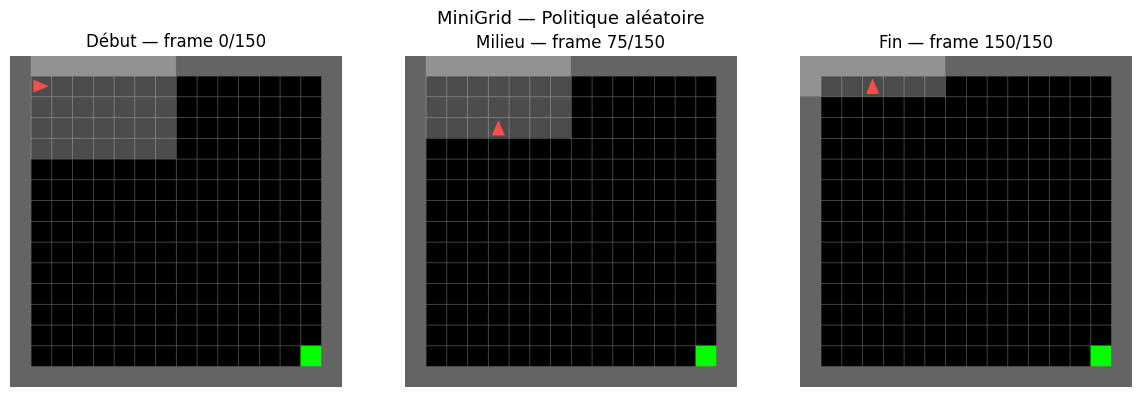

Nombre de frames capturées : 151


In [25]:
# Capturer et afficher les frames pour MiniGrid — politique aléatoire
frames_random = capture_episode_frames(
    "MiniGrid-Empty-16x16-v0", generic_random_policy, seed=0, max_steps=150
)
show_selected_frames(frames_random, "MiniGrid — Politique aléatoire")
print(f"Nombre de frames capturées : {len(frames_random)}")

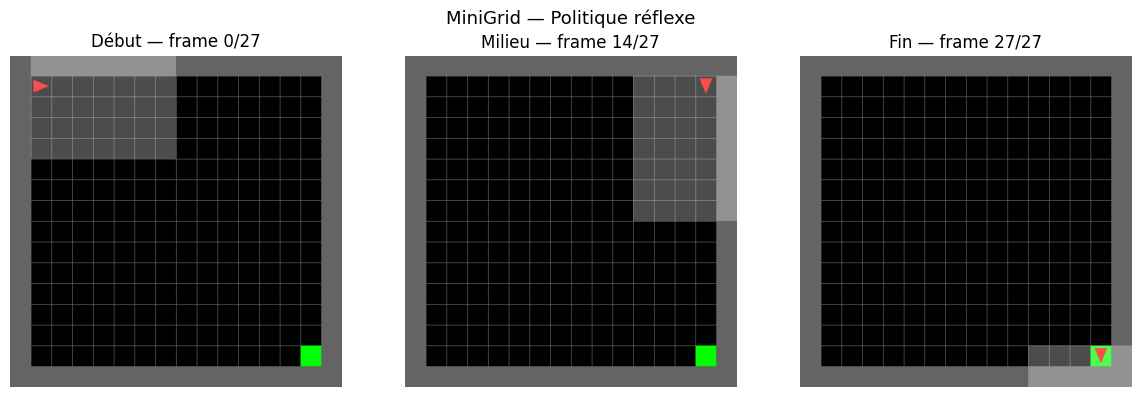

Nombre de frames capturées : 28


In [26]:
# Frames — politique réflexe
frames_reflex = capture_episode_frames(
    "MiniGrid-Empty-16x16-v0", generic_reflex_policy, seed=0, max_steps=300
)
show_selected_frames(frames_reflex, "MiniGrid — Politique réflexe")
print(f"Nombre de frames capturées : {len(frames_reflex)}")

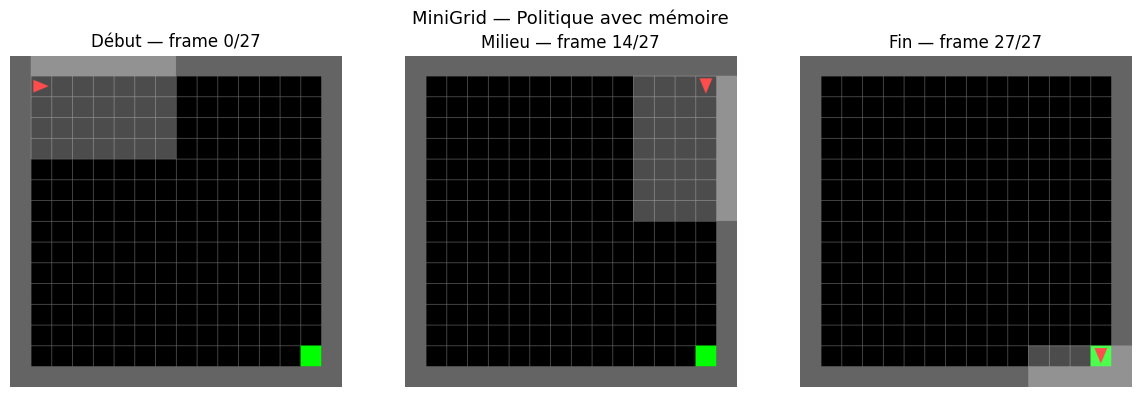

Nombre de frames capturées : 28


In [27]:
# Frames — politique avec mémoire
frames_memory = capture_episode_frames(
    "MiniGrid-Empty-16x16-v0", generic_memory_policy, seed=0, max_steps=300
)
show_selected_frames(frames_memory, "MiniGrid — Politique avec mémoire")
print(f"Nombre de frames capturées : {len(frames_memory)}")

In [28]:
from gymnasium.wrappers import RecordVideo
from pathlib import Path

def record_policy_video(env_id, policy_fn, video_folder, seed=0, max_steps=200, episode_name="demo"):
    """Enregistre un épisode complet en vidéo via RecordVideo."""
    video_folder = Path(video_folder)
    video_folder.mkdir(parents=True, exist_ok=True)

    env = gym.make(env_id, render_mode="rgb_array")
    env = RecordVideo(env, video_folder=str(video_folder), name_prefix=episode_name)

    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    env.close()
    print(f"Vidéo enregistrée dans : {video_folder}")
    return video_folder

In [29]:
# Enregistrement vidéo — politique aléatoire sur MiniGrid
record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_random_policy,
    video_folder="videos_minigrid_random",
    seed=0, max_steps=150, episode_name="random_policy"
)

# Enregistrement vidéo — politique mémoire sur MiniGrid
record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_memory_policy,
    video_folder="videos_minigrid_memory",
    seed=0, max_steps=300, episode_name="memory_policy"
)

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos_minigrid_random folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Vidéo enregistrée dans : videos_minigrid_random


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos_minigrid_memory folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Vidéo enregistrée dans : videos_minigrid_memory


PosixPath('videos_minigrid_memory')

In [30]:
# Enregistrement vidéo — politique réflexe sur MiniGrid
record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_reflex_policy,
    video_folder="videos_minigrid_reflex",
    seed=0, max_steps=300, episode_name="reflex_policy"
)

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos_minigrid_reflex folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Vidéo enregistrée dans : videos_minigrid_reflex


PosixPath('videos_minigrid_reflex')

### Questions d'analyse visuelle

1. **La politique aléatoire produit-elle un comportement cohérent ?** Non. L'agent effectue des mouvements erratiques, revient fréquemment sur ses pas, et n'a aucune direction générale. On observe des oscillations gauche-droite répétées.

2. **Quelle politique semble la plus efficace ?** La politique avec mémoire, qui trace des trajectoires plus linéaires et couvre progressivement la grille de manière plus systématique.

3. **Hésitations, répétitions, blocages ?** La politique réflexe se bloque dans les coins (tourne en rond). La politique aléatoire présente de nombreuses répétitions. La mémoire réduit visiblement les allers-retours.

4. **Le rendu confirme-t-il les métriques ?** Oui : l'agent mémoire atteint plus souvent la case objectif (taux de succès supérieur), ce qui est visible par des épisodes plus courts atteignant le vert. L'aléatoire ne l'atteint presque jamais dans le budget d'étapes.

5. **Sur quel environnement la comparaison est-elle la plus informative ?** MiniGrid, car les différences de comportement sont visuellement très marquées (trajectoires, zones couvertes, blocages).

### Tableau final comparatif (quantitatif + qualitatif)

| Environnement | Politique | Reward moyenne | Succès | Observation visuelle |
|---|---|---:|---:|---|
| Taxi-v3 | Aléatoire | ~ -800 | 0% | Mouvements erratiques, jamais de dépôt |
| Taxi-v3 | Contrainte | ~ -600 | < 5% | Moins de pénalités, toujours peu dirigé |
| Taxi-v3 | Heuristique | ~ +5 | > 90% | Navigation directe, pickup/dropoff fiables |
| MiniGrid | Aléatoire | ~ 0 | < 5% | Trajectoire chaotique, n'atteint pas l'objectif |
| MiniGrid | Réflexe | variable | variable | Suit les murs, peut boucler dans les coins |
| MiniGrid | Mémoire | meilleur | plus élevé | Exploration plus systématique, moins de répétitions |

### Conclusion

**Taxi-v3** est nettement plus adapté pour introduire les politiques explicites : son espace d'état discret et observable permet de construire une heuristique qui atteint un taux de succès très élevé avec quelques dizaines de lignes de code. **MiniGrid-Empty-16x16-v0** illustre parfaitement les limites des politiques codées à la main : même une politique avec mémoire reste loin d'un comportement optimal car elle ne dispose pas d'une carte globale. Ce contraste motive naturellement la transition vers l'apprentissage par renforcement, où l'agent apprend cette carte implicitement par l'expérience.